In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from pathlib import Path

In [18]:

from brain_image.data.alljoined_eeg2_dataset import AlljoinedEEG2Dataset, AlljoinedEEG2DatasetConfig


alljoined_path = Path("data/alljoined-1.6m")
c = AlljoinedEEG2DatasetConfig(subs=[1], num_workers=0)
d = AlljoinedEEG2Dataset(
    c, 
    split="test", 
    )


In [21]:
print(d.eeg.shape)

d.eeg.shape
#d.eeg[0].mean(), d.eeg[0].std(), d.eeg.min(), d.eeg.max()

torch.Size([1, 16217, 32, 250])


torch.Size([1, 16217, 32, 250])

In [19]:
d.train_eeg_stats[1]["mean"].shape, d.eeg[0].shape, d.eeg[0] + d.train_eeg_stats[1]["mean"]

(torch.Size([32, 250]),
 torch.Size([16217, 32, 250]),
 tensor([[[ 2.4228e-01,  5.0490e-02,  3.2428e-01,  ...,  1.4887e-01,
            1.7804e-02, -1.1211e-01],
          [-9.1377e-01, -1.0042e+00, -8.2962e-01,  ...,  3.7069e-01,
            4.5107e-01,  1.7409e-01],
          [-6.8450e-01, -3.2778e-01,  1.1971e-01,  ..., -1.0691e+00,
           -1.0262e+00, -7.7976e-01],
          ...,
          [-1.1171e+00, -1.2135e+00, -1.1559e+00,  ..., -5.4226e-01,
           -2.2676e-01, -1.4154e-01],
          [-5.6836e-01, -7.2031e-01, -7.9289e-01,  ...,  3.6470e-01,
            3.8777e-01,  3.9956e-01],
          [-2.8843e-01, -2.4740e-01, -1.5228e-01,  ..., -3.1636e-01,
           -3.2556e-01, -3.3547e-01]],
 
         [[ 1.4489e+00,  1.7406e+00,  1.8099e+00,  ...,  2.2912e-02,
           -2.7798e-01, -3.7827e-01],
          [-4.7409e-01, -2.0502e-01,  1.8516e-01,  ...,  3.2176e-01,
            3.2086e-01,  1.8654e-01],
          [-6.2907e-01, -6.1408e-01, -7.2604e-01,  ..., -1.4570e+00,
  

In [8]:
from brain_image.data.things_eeg2_dataset import ThingsEEG2Dataset, ThingsEEG2DatasetConfig


things_path = Path("data/things-eeg2")
c2 = ThingsEEG2DatasetConfig(subs=[1], num_workers=0)
d2 = ThingsEEG2Dataset(
    c2, 
    split="test", 
    )


In [84]:
def inspect_eeg(eeg):
    print("shape", eeg.shape)
    print("mean", eeg.mean(axis=0).mean())
    print("std", eeg.std(axis=0).mean())
    print("min", eeg.min())
    print("max", eeg.max())
    print("norm", np.linalg.norm(eeg, axis=1).mean())

eeg1 = preprocess_alljoined(d.eeg).reshape(-1, d.config.num_channels, d.config.time_length).flatten(1).numpy() # merge subs and trials, then flatten
eeg2 = d2.eeg.reshape(-1, d2.config.num_channels, d2.config.time_length).flatten(1).numpy() # merge subs and trials, then flatten

print("alljoined")
inspect_eeg(eeg1)
print()
print("eeg")
inspect_eeg(eeg2)

alljoined
shape (16217, 8000)
mean 1.1961423266815025e-18
std 0.9999691676815564
min -74.97839015372851
max 84.35518805739385
norm 80.39750912378142

eeg
shape (200, 15750)
mean -0.009592084155981203
std 0.13203177272967154
min -2.0924231432645164
max 1.6370437233820745
norm 24.677332252407822


In [ ]:
import torch


def preprocess_alljoined(eeg: torch.Tensor):
    num_subs = eeg.size(0)
    num_trials = eeg.size(1)
    num_channels = eeg.size(2)
    num_timesteps = eeg.size(3)

    eeg = eeg.reshape(num_subs * num_trials, num_channels, num_timesteps)
    mean = eeg.mean(dim=0, keepdim=True)
    std = eeg.std(dim=0, keepdim=True)
    eeg = (eeg - mean) / std

    eeg = eeg.reshape(num_subs, num_trials, num_channels, num_timesteps)

   
    return eeg

def truncate_data(data: torch.Tensor, trunc_percentile: float):
    sorted_values = data.flatten().abs().sort(descending=False).values
    trunc_idx = int(trunc_percentile * len(sorted_values))
    trunc_max = sorted_values[trunc_idx]
    data[data > trunc_max] = trunc_max
    data[data < -trunc_max] = -trunc_max
    return data


peeg = preprocess_alljoined( truncate_data(d.eeg, 0.95))

(16217, 32, 250)


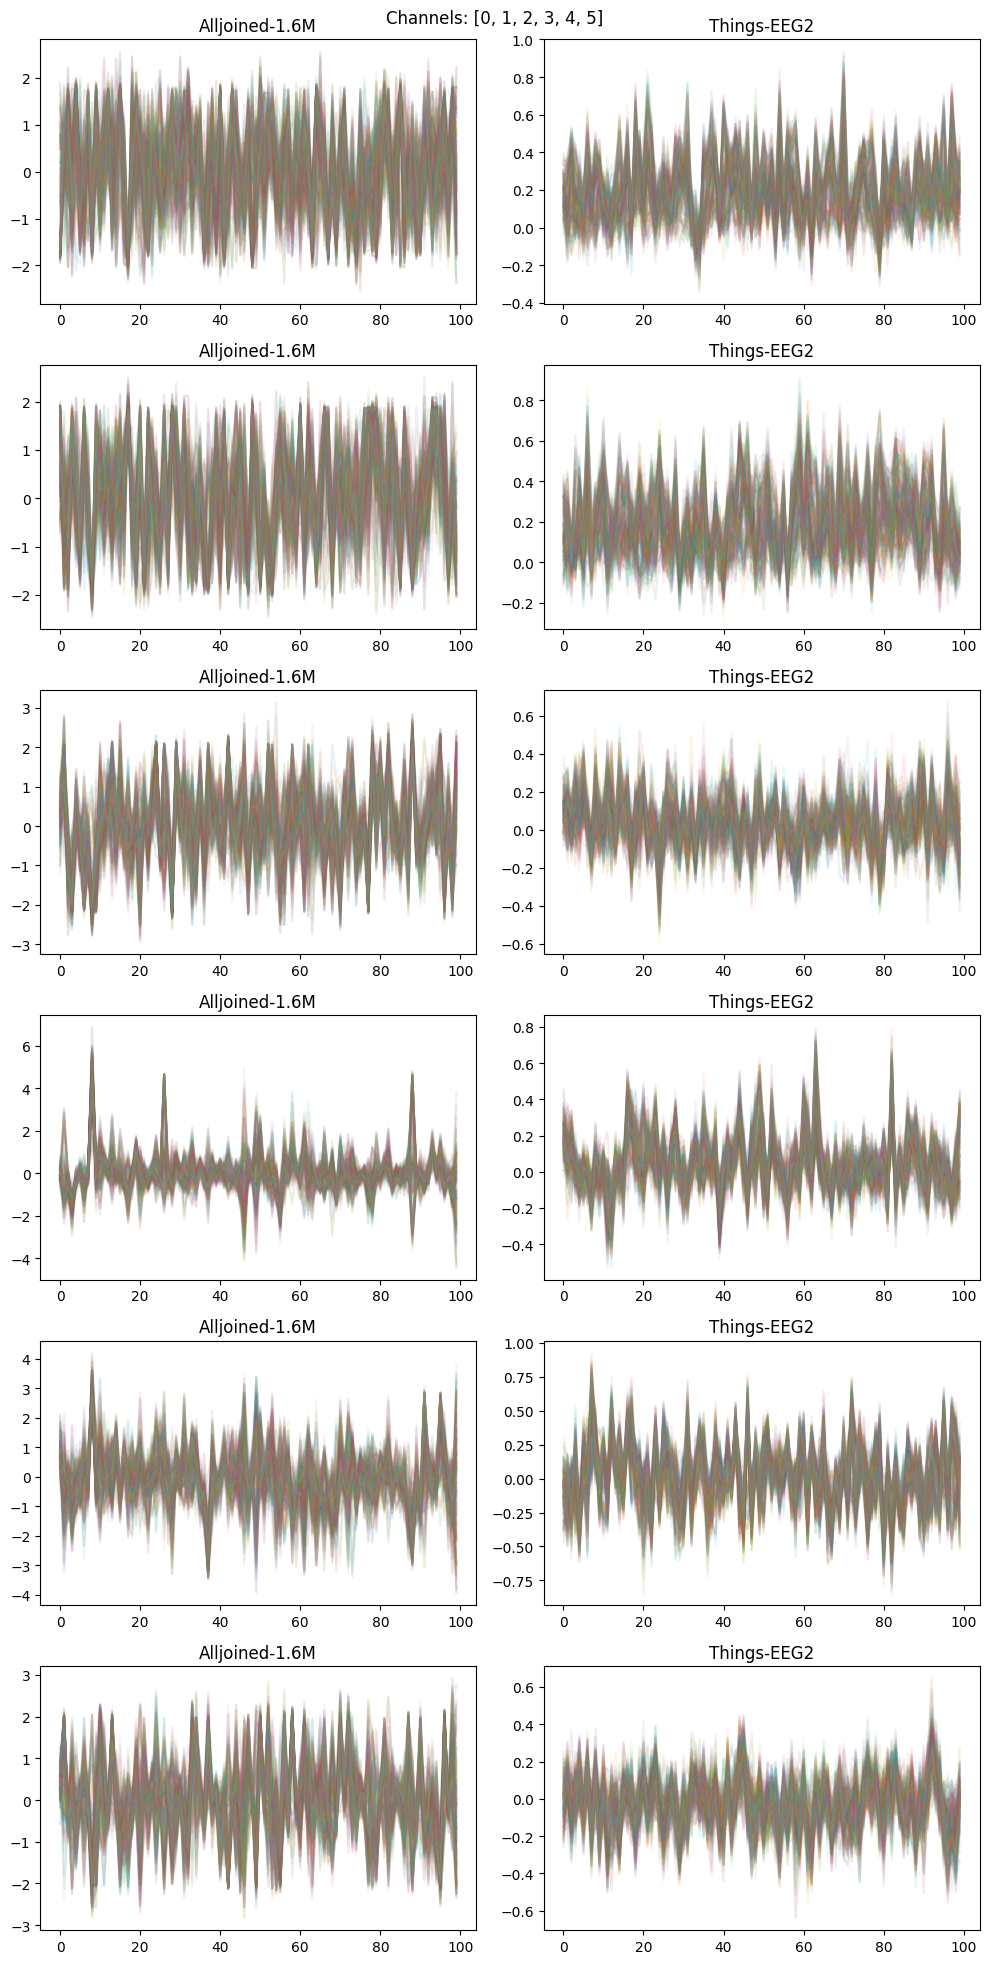

In [99]:
import numpy as np
import matplotlib.pyplot as plt

n_plots = 100
plt_seed = 42
np.random.seed(plt_seed)

eeg1 = peeg[0].numpy()
eeg2 = d2.eeg[0].numpy()
print(eeg1.shape)

idxs = np.random.choice(len(eeg1), n_plots, replace=False)
idxs2 = np.random.choice(len(eeg2), n_plots, replace=False)

cs = [0, 1, 2, 3, 4, 5]

plt.figure(figsize=(10, 20))
plt.suptitle(f"Channels: {cs}")


for c in cs:
    plt.subplot(len(cs), 2, 2*c+1)
    plt.plot(eeg1[idxs, c], alpha=0.1);
    plt.title("Alljoined-1.6M")
    plt.subplot(len(cs), 2, 2*c+2)
    plt.plot(eeg2[idxs2, c], alpha=0.1);
    plt.title("Things-EEG2")

plt.tight_layout()

...;

In [ ]:
import umap


umap_1 = umap.UMAP(random_state=42)
d_eeg_2d = umap_1.fit_transform(eeg1)

/home/gasparyanartur/dev/brain-image-implementation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


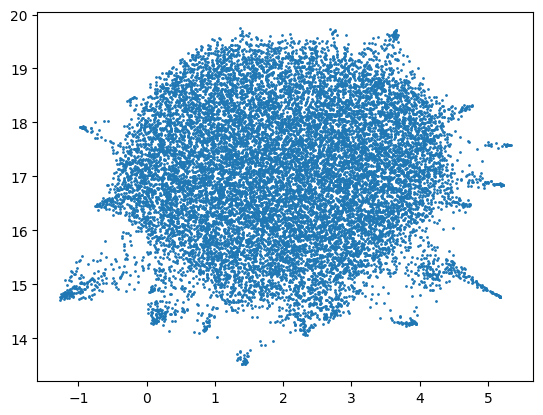

In [36]:
import matplotlib.pyplot as plt
plt.scatter(d_eeg_2d[:, 0], d_eeg_2d[:, 1], s=1)

In [43]:
umap_2 = umap.UMAP(random_state=42)
d2_eeg_2d = umap_2.fit_transform(eeg2)

/home/gasparyanartur/dev/brain-image-implementation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


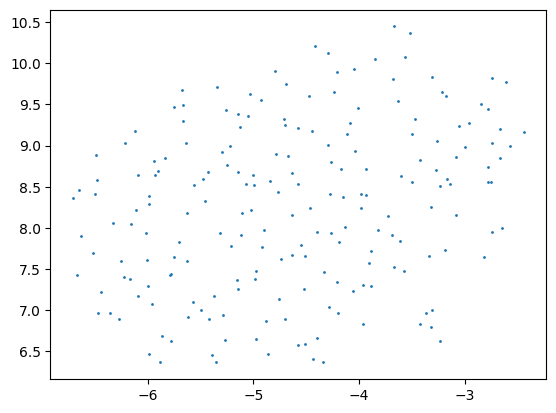

In [44]:
plt.scatter(d2_eeg_2d[:, 0], d2_eeg_2d[:, 1], s=1)

In [30]:
d.eeg.flatten(1).numpy().shape

(1, 129736000)

In [75]:
#d.meta_subs[1], len(d), d.eeg.shape
all_image_paths = d.get_image_paths()
for i in range(len(d)):
    assert Path(d[i]["img_path"]) in all_image_paths, d[i]["img_path"]

In [69]:
from brain_image.data.alljoined_eeg2_dataset import query_metadata


query_metadata(d.metadata, sub=1)

,image_path,subject,session,block_id,sequence_id,sequence_image_id,partition,category_name,category_num,category_img_num
0,data/alljoined-1.6m/stimuli/images/16641.jpg,1,1,1,1,1,test,jukebox,101,0
1,data/alljoined-1.6m/stimuli/images/16733.jpg,1,1,1,1,2,test,wallpaper,193,0
2,data/alljoined-1.6m/stimuli/images/16637.jpg,1,1,1,1,3,test,ice_cube,97,0
3,data/alljoined-1.6m/stimuli/images/16683.jpg,1,1,1,1,4,test,pug,143,0
4,data/alljoined-1.6m/stimuli/images/16558.jpg,1,1,1,1,5,test,bonnet,18,0
...,...,...,...,...,...,...,...,...,...,...
66713,data/alljoined-1.6m/stimuli/images/16660.jpg,1,4,4,51,14,test,nightstand,120,0
66714,data/alljoined-1.6m/stimuli/images/16560.jpg,1,4,4,51,15,test,brace,20,0
66715,data/alljoined-1.6m/stimuli/images/16567.jpg,1,4,4,51,16,test,bush,27,0
66716,data/alljoined-1.6m/stimuli/images/16729.jpg,1,4,4,51,17,test,turkey,189,0


In [72]:
(d.get_image_paths())

[PosixPath('data/alljoined-1.6m/stimuli/images/16540.jpg'),
 PosixPath('data/alljoined-1.6m/stimuli/images/16541.jpg'),
 PosixPath('data/alljoined-1.6m/stimuli/images/16542.jpg'),
 PosixPath('data/alljoined-1.6m/stimuli/images/16543.jpg'),
 PosixPath('data/alljoined-1.6m/stimuli/images/16544.jpg'),
 PosixPath('data/alljoined-1.6m/stimuli/images/16545.jpg'),
 PosixPath('data/alljoined-1.6m/stimuli/images/16546.jpg'),
 PosixPath('data/alljoined-1.6m/stimuli/images/16547.jpg'),
 PosixPath('data/alljoined-1.6m/stimuli/images/16548.jpg'),
 PosixPath('data/alljoined-1.6m/stimuli/images/16549.jpg'),
 PosixPath('data/alljoined-1.6m/stimuli/images/16550.jpg'),
 PosixPath('data/alljoined-1.6m/stimuli/images/16551.jpg'),
 PosixPath('data/alljoined-1.6m/stimuli/images/16552.jpg'),
 PosixPath('data/alljoined-1.6m/stimuli/images/16553.jpg'),
 PosixPath('data/alljoined-1.6m/stimuli/images/16554.jpg'),
 PosixPath('data/alljoined-1.6m/stimuli/images/16555.jpg'),
 PosixPath('data/alljoined-1.6m/stimuli/

In [34]:
print(c)

data_path=PosixPath('data/alljoined-1.6m') batch_size=128 val_batch_size=None test_batch_size=None limit_train_size=1.0 limit_val_size=1.0 limit_test_size=1.0 num_workers=0 dataset='alljoined-eeg2' preload_cache=True img_dir='stimuli/images' preprocessed_eeg_dir='preprocessed-eeg' subs=[4]


In [37]:
for img in d.get_image_paths():
    assert img.exists()

    x = d.get_embeddings(img)
    print(x.keys())

dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_keys([])
dict_k

In [8]:
len(set(d.get_image_paths()))

16540

In [6]:
d[0]

{'img_path': 'data/alljoined-1.6m/stimuli/images/11134.jpg',
 'eeg_data': tensor([[ 1.4707,  0.6131, -0.0392,  ..., -1.4895, -1.0901, -0.6889],
         [ 0.2924,  0.2572, -0.2138,  ...,  1.0086,  0.6359,  0.5405],
         [ 2.0265,  1.7682,  1.7183,  ..., -1.0114, -1.2070, -1.6336],
         ...,
         [ 1.7380,  1.4060,  1.2940,  ..., -1.1314, -0.9210, -1.0182],
         [ 0.1188,  0.0057,  0.0419,  ..., -0.6638, -0.5047, -0.4309],
         [ 0.6723,  0.5950,  0.4942,  ..., -0.8718, -0.8778, -0.8880]],
        dtype=torch.float64),
 'idx': 0,
 'sub': 1}